In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Input , Dropout

In [59]:

df = pd.read_csv(
    "/content/Accident_Information.csv",
    engine='python',
    on_bad_lines='skip'
)

In [60]:
df.shape

(2047256, 34)

In [61]:
df.isnull().sum()

,0
Accident_Index,0
1st_Road_Class,0
1st_Road_Number,2
2nd_Road_Class,844272
2nd_Road_Number,17593
Accident_Severity,0
Carriageway_Hazards,2007807
Date,0
Day_of_Week,0
Did_Police_Officer_Attend_Scene_of_Accident,278


In [62]:
df = df[['Latitude', 'Longitude', 'Accident_Severity',
         'Weather_Conditions', 'Road_Type',
         'Light_Conditions', 'Time', 'Urban_or_Rural_Area']]


In [63]:
df = df.dropna()

In [64]:
grid_size = 0.02   # ~1 km grid

df['lat_grid'] = (df['Latitude'] // grid_size).astype(int)
df['lon_grid'] = (df['Longitude'] // grid_size).astype(int)

In [65]:
grid_counts = df.groupby(['lat_grid', 'lon_grid']).size().reset_index(name='acc_count')

df = df.merge(grid_counts, on=['lat_grid', 'lon_grid'])

threshold = 30
df['is_hotspot'] = (df['acc_count'] > threshold).astype(int)

In [66]:
le = LabelEncoder()

categorical_cols = ['Accident_Severity','Weather_Conditions', 'Road_Type',
                    'Light_Conditions', 'Urban_or_Rural_Area']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Time → hour
df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour
df = df.dropna()

/tmp/ipykernel_1156/62920181.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour


In [67]:
df.shape

(2046925, 12)

In [70]:
X = df[['lat_grid', 'lon_grid', 'Accident_Severity',
        'Weather_Conditions', 'Road_Type',
        'Light_Conditions', 'Time', 'Urban_or_Rural_Area']]

y = df['is_hotspot']

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [72]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [73]:
df.dtypes

,0
Latitude,float64
Longitude,float64
Accident_Severity,int64
Weather_Conditions,int64
Road_Type,int64
Light_Conditions,int64
Time,int32
Urban_or_Rural_Area,int64
lat_grid,int64
lon_grid,int64


In [74]:
model = Sequential()

# Input Layer
model.add(Input(shape=(X_train.shape[1],)))

# Hidden Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [75]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_data=(X_test, y_test),

)

Epoch 1/10
6397/6397 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.8838 - loss: 0.2397 - val_accuracy: 0.8927 - val_loss: 0.2284
Epoch 2/10
6397/6397 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.8905 - loss: 0.2295 - val_accuracy: 0.8939 - val_loss: 0.2239
Epoch 3/10
6397/6397 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8921 - loss: 0.2265 - val_accuracy: 0.8955 - val_loss: 0.2212
Epoch 4/10
6397/6397 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.8929 - loss: 0.2247 - val_accuracy: 0.8955 - val_loss: 0.2194
Epoch 5/10
6397/6397 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8937 - loss: 0.2236 - val_accuracy: 0.8969 - val_loss: 0.2185
Epoch 6/10
6397/6397 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8941 - loss: 0.2227 - val_accuracy: 0.8974 - val_loss: 0.2172
Epoch 7/10
6397/6397 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8947 - loss: 0.2221 - val_accuracy: 0.8986 - val_loss: 0.2168
Epoch 8/10
6397/6397 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8949 - loss: 0

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


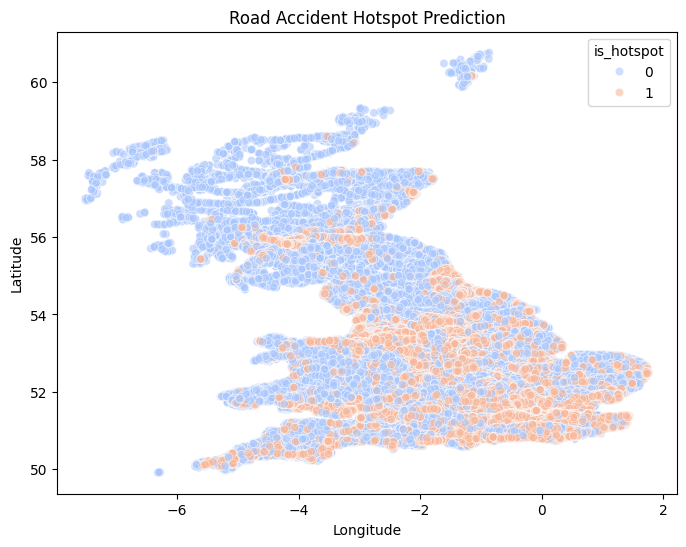

In [76]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Longitude'],
    y=df['Latitude'],
    hue=df['is_hotspot'],
    palette='coolwarm',
    alpha=0.6
)

plt.title("Road Accident Hotspot Prediction")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [77]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

# Predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

12794/12794 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - accuracy: 0.8984 - loss: 0.2155
Accuracy: 0.8984159231185913
12794/12794 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.67      0.66     60477
           1       0.94      0.94      0.94    348908

    accuracy                           0.90    409385
   macro avg       0.80      0.80      0.80    409385
weighted avg       0.90      0.90      0.90    409385


Confusion Matrix:

[[ 40470  20007]
 [ 21580 327328]]


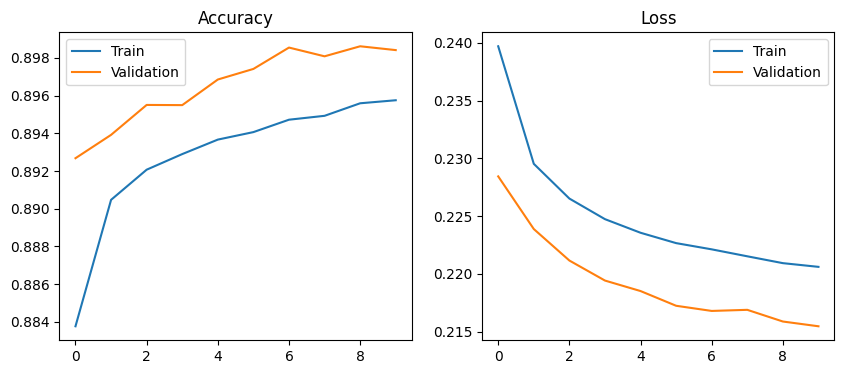

In [78]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()

plt.show()